# Utvidelse 04 — Kjernekraft, gass+CCS, hydrogen, ammoniakk og syntetisk metan som separate lag

Hovednotebooken pakker alt ikke-batteri inn i én pedagogisk parameter (`firm_other_gw`). Her splitter vi opp i **separate lag** med hver sin egen effekt, brensels-/lagringskost og rolle:

| Lag | Type | Kommentar |
|---|---|---|
| Kjernekraft | Baselast | Lav OPEX, stiv, dyr CAPEX |
| Gass + CCS | Mid/peak | Brenseltilgjengelig, CO₂-håndtering nødvendig |
| Hydrogen-CCGT | Peak | Krever H₂-lager + transport |
| Ammoniakk-CCGT | Peak | NH₃ kan importeres som flytende energibærer |
| Syntetisk metan | Peak | Bruker eksisterende gassinfrastruktur |

Vi modellerer ikke kjemi; bare **dekningsbidrag** og **omtrentlig brutto kapitalbinding** under hendelsen.


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
candidates = [HERE / "data" / "defaults.json", HERE.parent.parent / "data" / "defaults.json", HERE.parent / "data" / "defaults.json"]
defaults = json.loads(next(p for p in candidates if p.exists()).read_text())["defaults"]
residual_gap_gw = defaults["residual_gap_gw"]
event_days = defaults["event_days"]
hours = event_days * 24


## Oslo-år som felles målestokk

I alle utvidelsene bruker vi samme norske normalisering: **Oslo ≈ 1 GW kontinuerlig ≈ 8,76 TWh per år**. Det gjør GW- og TWh-tall lettere å lese uten å blande effekt med energi.


In [ ]:
HOURS_PER_YEAR = 8760

anchors = {
    "Norsk husholdning": {"energy_kwh_per_year": 14_700, "source": "SSB 2024"},
    "Bergen kommune": {"energy_twh_per_year": 3.4898, "source": "SSB tabell 14490, 2024"},
    "Oslo kommune": {"energy_twh_per_year": 8.7589, "source": "SSB tabell 14490, 2024"},
    "Statkraft Norge": {"energy_twh_per_year": 51.2, "source": "Statkraft 2025"},
    "Norge forbruk inkl. tap": {"energy_twh_per_year": 139.2, "source": "Statnett 2025"},
    "Norge produksjon": {"energy_twh_per_year": 162.0, "source": "Statnett 2025"},
}


def twh_to_average_gw(twh_per_year):
    return twh_per_year / (HOURS_PER_YEAR / 1000)


def gw_to_twh_per_year(gw):
    return gw * HOURS_PER_YEAR / 1000


def twh_to_oslo_years(twh):
    return twh / anchors["Oslo kommune"]["energy_twh_per_year"]


def oslo_average_gw():
    return twh_to_average_gw(anchors["Oslo kommune"]["energy_twh_per_year"])


def describe_energy(twh):
    return {
        "TWh": twh,
        "Oslo-år": twh_to_oslo_years(twh),
        "Bergen-år": twh / anchors["Bergen kommune"]["energy_twh_per_year"],
        "Statkraft Norge-år": twh / anchors["Statkraft Norge"]["energy_twh_per_year"],
        "Norge-forbruksår": twh / anchors["Norge forbruk inkl. tap"]["energy_twh_per_year"],
        "Gjennomsnittlig GW i ett år": twh_to_average_gw(twh),
    }


## Lag-definisjon

Hver teknologi får:

- `power_GW`: installert effekt tilgjengelig **for denne hendelsen**.
- `availability`: fraksjon av effekten som faktisk leverer (driftsstans, brennstofftilgang).
- `capex_USD_per_kW`: pedagogiske 2025-størrelsesordener fra IEA / NREL ATB.
- `fuel_USD_per_MWh`: tenkt brensels-/lagringskostnad, ikke marginalpris.


In [2]:
layers = pd.DataFrame([
    {"layer": "Kjernekraft",       "power_GW": 100, "availability": 0.85, "capex_USD_per_kW": 8000, "fuel_USD_per_MWh":  10},
    {"layer": "Gass + CCS",        "power_GW":  60, "availability": 0.90, "capex_USD_per_kW": 2800, "fuel_USD_per_MWh":  90},
    {"layer": "Hydrogen-CCGT",     "power_GW":  30, "availability": 0.70, "capex_USD_per_kW": 1500, "fuel_USD_per_MWh": 180},
    {"layer": "Ammoniakk-CCGT",    "power_GW":  20, "availability": 0.70, "capex_USD_per_kW": 1700, "fuel_USD_per_MWh": 200},
    {"layer": "Syntetisk metan",   "power_GW":  20, "availability": 0.80, "capex_USD_per_kW": 1400, "fuel_USD_per_MWh": 220},
])
layers["effective_GW"]  = layers["power_GW"] * layers["availability"]
layers["energy_TWh"]    = layers["effective_GW"] * hours / 1000
layers["energy_Oslo_aar"] = layers["energy_TWh"].map(twh_to_oslo_years)
layers["fuel_cost_bn_USD"] = layers["energy_TWh"] * 1000 * layers["fuel_USD_per_MWh"] / 1e6
layers


,layer,power_GW,availability,capex_USD_per_kW,fuel_USD_per_MWh,effective_GW,energy_TWh,fuel_cost_bn_USD
0,Kjernekraft,100,0.85,8000,10,85.0,20.40,0.2040
1,Gass + CCS,60,0.90,2800,90,54.0,12.96,1.1664
2,Hydrogen-CCGT,30,0.70,1500,180,21.0,5.04,0.9072
3,Ammoniakk-CCGT,20,0.70,1700,200,14.0,3.36,0.6720
4,Syntetisk metan,20,0.80,1400,220,16.0,3.84,0.8448


## Stables under residualbehovet


In [3]:
total_firm_gw = layers["effective_GW"].sum()
remaining_gw  = max(residual_gap_gw - total_firm_gw, 0)
print(f"Sum 'firm' effekt fra disse lagene: {total_firm_gw:.0f} GW")
print(f"Restbehov (batterier/import/DR):    {remaining_gw:.0f} GW")
print(f"Restbehovet tilsvarer:              {remaining_gw/oslo_average_gw():.0f} Oslo i snitteffekt")
print(f"Andel av residual gap dekket:       {100*min(total_firm_gw,residual_gap_gw)/residual_gap_gw:.0f} %")


Sum 'firm' effekt fra disse lagene: 190 GW
Restbehov (batterier/import/DR):    60 GW
Andel av residual gap dekket:       76 %


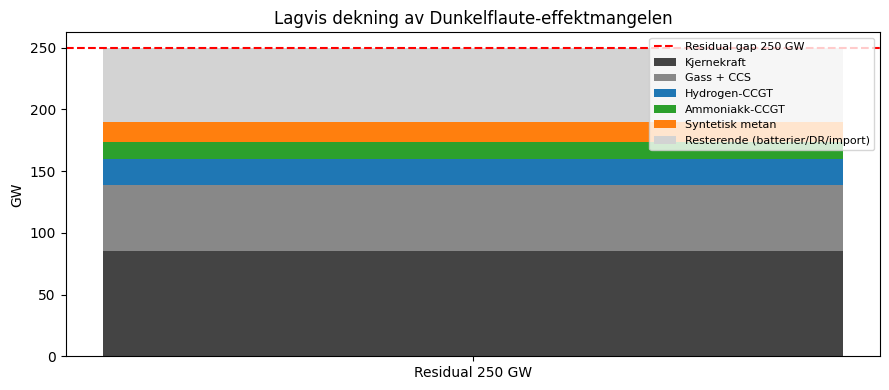

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
bottom = 0
colors = ["#444", "#888", "#1f77b4", "#2ca02c", "#ff7f0e"]
for (_, row), c in zip(layers.iterrows(), colors):
    ax.bar("Residual 250 GW", row["effective_GW"], bottom=bottom, label=row["layer"], color=c)
    bottom += row["effective_GW"]
ax.bar("Residual 250 GW", max(residual_gap_gw - bottom, 0), bottom=bottom,
       label="Resterende (batterier/DR/import)", color="lightgrey")
ax.axhline(residual_gap_gw, color="red", linestyle="--", label="Residual gap 250 GW")
ax.set_ylabel("GW")
ax.set_title("Lagvis dekning av Dunkelflaute-effektmangelen")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## Læring

- Hver av disse teknologiene har **forskjellig rolle**: kjernekraft som baselast, gass+CCS som mid-merit, hydrogen/ammoniakk/syn-metan som energirik peak.
- Brensel- og lagringskost varierer en størrelsesorden mellom lagene. Det avgjør hvilket lag som **bør** ligge nederst i merit-orden.
- Når disse lagene er på plass, krymper **batteriets oppgave** kraftig — fra «alt» til «timer-skala fleksibilitet og rampehjelp».
- En komplett analyse må også modellere **brenslets opprinnelse** (importert NH₃, innenlandsk H₂ fra elektrolyse, biogas …) — ikke gjort her.
